In [13]:
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
sys.path.append('..') 

In [14]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

dpi_num = 100

In [15]:
dirs = {
    "2q": {
        "Brydges": r"..\analytical_solution\results\2q",
        "stella":    r"..\models\outputs\2q\outputs_attention",
        "MLP":    r"..\models\outputs\2q\outputs_MLP"
    },
    "4q": {
        "Brydges": r"..\analytical_solution\results\4q",
        "stella":    r"..\models\outputs\4q\outputs_attention",
        "MLP":    r"..\models\outputs\4q\outputs_MLP"
    }
}

Nm_list_2 = np.logspace(np.log10(1), np.log10(200), num=10, dtype=int)
Nu_list_2 = np.linspace(1, 100, num=10, dtype=int)

Nm_list_4 = np.logspace(np.log10(1), np.log10(200), num=10, dtype=int)
Nu_list_4 = np.linspace(1, 500, num=10, dtype=int)

In [16]:
intercept_values_brydges = []
slope_vals_brydges = []
intercept_values_attn = []
slope_vals_attn = []
intercept_values_mlp = []
slope_vals_mlp = []

for Nm in Nm_list_2:
  true = np.loadtxt(os.path.join(dirs["2q"]["Brydges"], f"{Nm}shot_100unitary_true.txt"))
  pred = np.loadtxt(os.path.join(dirs["2q"]["Brydges"], f"{Nm}shot_100unitary_predicted.txt"))

  b, m = np.polynomial.polynomial.polyfit(true, pred, 1)
  slope_vals_brydges.append(m)
  intercept_values_brydges.append(b)

  true = np.loadtxt(os.path.join(dirs["2q"]["stella"], f"{Nm}shot_100unitary_true.txt"))
  pred = np.loadtxt(os.path.join(dirs["2q"]["stella"], f"{Nm}shot_100unitary_predicted.txt"))

  b, m = np.polynomial.polynomial.polyfit(true, pred, 1)
  slope_vals_attn.append(m)
  intercept_values_attn.append(b)

  true = np.loadtxt(os.path.join(dirs["2q"]["MLP"], f"{Nm}shot_100unitary_true.txt"))
  pred = np.loadtxt(os.path.join(dirs["2q"]["MLP"], f"{Nm}shot_100unitary_predicted.txt"))

  b, m = np.polynomial.polynomial.polyfit(true, pred, 1)
  slope_vals_mlp.append(m)
  intercept_values_mlp.append(b)


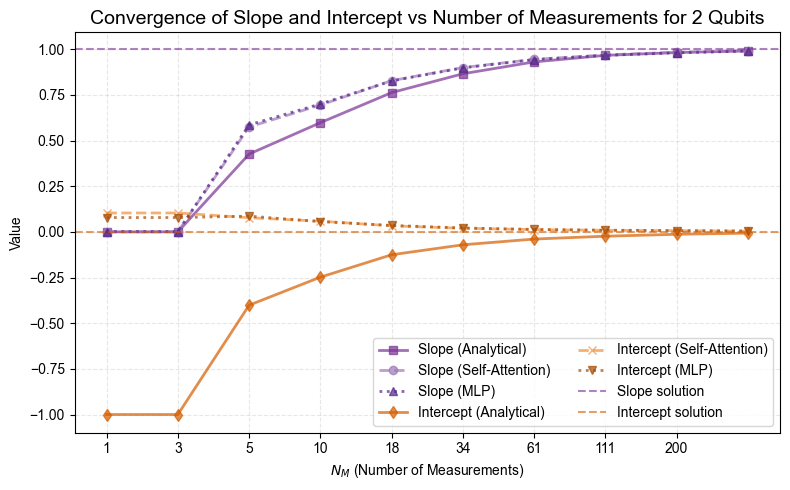

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(slope_vals_brydges, label="Slope (Analytical)", color="#7B3294", linewidth=2, marker="s", alpha=0.7)
plt.plot(slope_vals_attn, label="Slope (Self-Attention)", color="#9E77B8", linewidth=2, marker="o", linestyle="--", alpha=0.7)

plt.plot(slope_vals_mlp, label="Slope (MLP)", color="#542788", linewidth=2, marker="^", linestyle=":", alpha=0.7)
plt.plot(intercept_values_brydges, label="Intercept (Analytical)", color="#D55E00", linewidth=2, marker="d", alpha=0.7)

plt.plot(intercept_values_attn, label="Intercept (Self-Attention)", color="#F18F3B", linewidth=2, marker="x", linestyle="--", alpha=0.7)
plt.plot(intercept_values_mlp, label="Intercept (MLP)", color="#A64B00", linewidth=2, marker="v", linestyle=":", alpha=0.7)

plt.axhline(1, linestyle="--", alpha=0.6, color="#7B3294", label="Slope solution")
plt.axhline(0, linestyle="--", alpha=0.6, color="#D55E00", label="Intercept solution")

plt.title("Convergence of Slope and Intercept vs Number of Measurements for 2 Qubits", fontsize=14)

unique_uvals = np.unique(Nm_list_2)
plt.xticks(range(len(unique_uvals)), labels=unique_uvals.astype(int))

plt.xlabel(r"$N_M$ (Number of Measurements)")
plt.ylabel("Value")

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="best", frameon=True, ncol=2)

plt.savefig(f"Qubits2_slope_intercept_NM.pdf", format="pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()

In [18]:
intercept_values_brydges = []
slope_vals_brydges = []
intercept_values_attn = []
slope_vals_attn = []
intercept_values_mlp = []
slope_vals_mlp = []

for Nu in Nu_list_2:
  true = np.loadtxt(os.path.join(dirs["2q"]["Brydges"], f"200shot_{Nu}unitary_true.txt"))
  pred = np.loadtxt(os.path.join(dirs["2q"]["Brydges"], f"200shot_{Nu}unitary_predicted.txt"))

  b, m = np.polynomial.polynomial.polyfit(true, pred, 1)
  slope_vals_brydges.append(m)
  intercept_values_brydges.append(b)

  true = np.loadtxt(os.path.join(dirs["2q"]["stella"], f"200shot_{Nu}unitary_true.txt"))
  pred = np.loadtxt(os.path.join(dirs["2q"]["stella"], f"200shot_{Nu}unitary_predicted.txt"))

  b, m = np.polynomial.polynomial.polyfit(true, pred, 1)
  slope_vals_attn.append(m)
  intercept_values_attn.append(b)

  true = np.loadtxt(os.path.join(dirs["2q"]["MLP"], f"200shot_{Nu}unitary_true.txt"))
  pred = np.loadtxt(os.path.join(dirs["2q"]["MLP"], f"200shot_{Nu}unitary_predicted.txt"))

  b, m = np.polynomial.polynomial.polyfit(true, pred, 1)
  slope_vals_mlp.append(m)
  intercept_values_mlp.append(b)


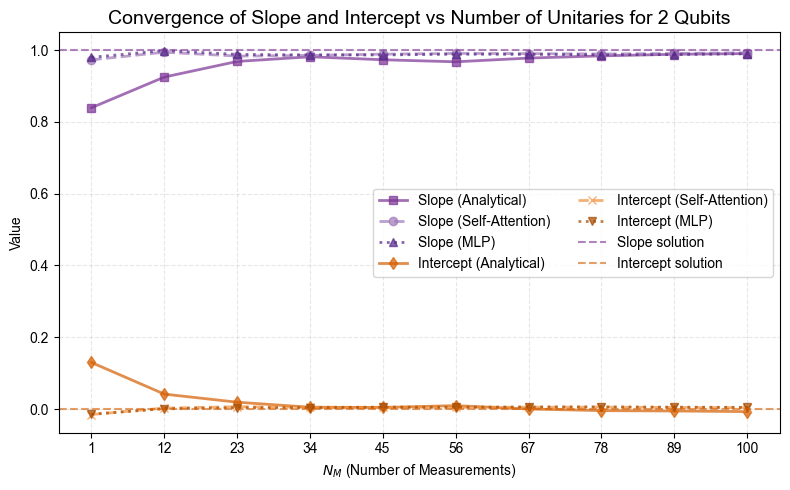

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(slope_vals_brydges, label="Slope (Analytical)", color="#7B3294", linewidth=2, marker="s", alpha=0.7)
plt.plot(slope_vals_attn, label="Slope (Self-Attention)", color="#9E77B8", linewidth=2, marker="o", linestyle="--", alpha=0.7)

plt.plot(slope_vals_mlp, label="Slope (MLP)", color="#542788", linewidth=2, marker="^", linestyle=":", alpha=0.7)
plt.plot(intercept_values_brydges, label="Intercept (Analytical)", color="#D55E00", linewidth=2, marker="d", alpha=0.7)

plt.plot(intercept_values_attn, label="Intercept (Self-Attention)", color="#F18F3B", linewidth=2, marker="x", linestyle="--", alpha=0.7)
plt.plot(intercept_values_mlp, label="Intercept (MLP)", color="#A64B00", linewidth=2, marker="v", linestyle=":", alpha=0.7)

plt.axhline(1, linestyle="--", alpha=0.6, color="#7B3294", label="Slope solution")
plt.axhline(0, linestyle="--", alpha=0.6, color="#D55E00", label="Intercept solution")

plt.title("Convergence of Slope and Intercept vs Number of Unitaries for 2 Qubits", fontsize=14)

unique_uvals = np.unique(Nu_list_2)
plt.xticks(range(len(unique_uvals)), labels=unique_uvals.astype(int))

plt.xlabel(r"$N_M$ (Number of Measurements)")
plt.ylabel("Value")

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="best", frameon=True, ncol=2)

plt.savefig(f"Qubits2_slope_intercept_NU.pdf", format="pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()

In [20]:
intercept_values_brydges = []
slope_vals_brydges = []
intercept_values_attn = []
slope_vals_attn = []
intercept_values_mlp = []
slope_vals_mlp = []

for Nm in Nm_list_4:
  true = np.loadtxt(os.path.join(dirs["4q"]["Brydges"], f"{Nm}shot_500unitary_true.txt"))
  pred = np.loadtxt(os.path.join(dirs["4q"]["Brydges"], f"{Nm}shot_500unitary_predicted.txt"))

  b, m = np.polynomial.polynomial.polyfit(true, pred, 1)
  slope_vals_brydges.append(m)
  intercept_values_brydges.append(b)

  true = np.loadtxt(os.path.join(dirs["4q"]["stella"], f"{Nm}shot_500unitary_true.txt"))
  pred = np.loadtxt(os.path.join(dirs["4q"]["stella"], f"{Nm}shot_500unitary_predicted.txt"))

  b, m = np.polynomial.polynomial.polyfit(true, pred, 1)
  slope_vals_attn.append(m)
  intercept_values_attn.append(b)

  true = np.loadtxt(os.path.join(dirs["4q"]["MLP"], f"{Nm}shot_500unitary_true.txt"))
  pred = np.loadtxt(os.path.join(dirs["4q"]["MLP"], f"{Nm}shot_500unitary_predicted.txt"))

  b, m = np.polynomial.polynomial.polyfit(true, pred, 1)
  slope_vals_mlp.append(m)
  intercept_values_mlp.append(b)


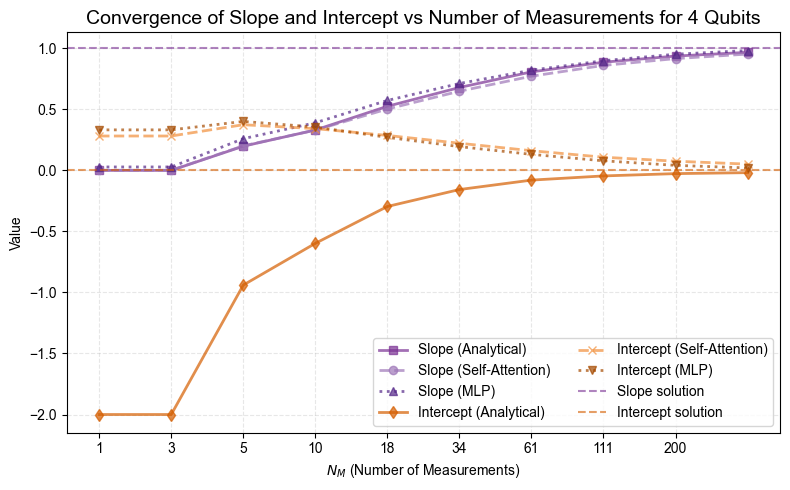

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(slope_vals_brydges, label="Slope (Analytical)", color="#7B3294", linewidth=2, marker="s", alpha=0.7)
plt.plot(slope_vals_attn, label="Slope (Self-Attention)", color="#9E77B8", linewidth=2, marker="o", linestyle="--", alpha=0.7)

plt.plot(slope_vals_mlp, label="Slope (MLP)", color="#542788", linewidth=2, marker="^", linestyle=":", alpha=0.7)
plt.plot(intercept_values_brydges, label="Intercept (Analytical)", color="#D55E00", linewidth=2, marker="d", alpha=0.7)

plt.plot(intercept_values_attn, label="Intercept (Self-Attention)", color="#F18F3B", linewidth=2, marker="x", linestyle="--", alpha=0.7)
plt.plot(intercept_values_mlp, label="Intercept (MLP)", color="#A64B00", linewidth=2, marker="v", linestyle=":", alpha=0.7)

plt.axhline(1, linestyle="--", alpha=0.6, color="#7B3294", label="Slope solution")
plt.axhline(0, linestyle="--", alpha=0.6, color="#D55E00", label="Intercept solution")

plt.title("Convergence of Slope and Intercept vs Number of Measurements for 4 Qubits", fontsize=14)

unique_uvals = np.unique(Nm_list_4)
plt.xticks(range(len(unique_uvals)), labels=unique_uvals.astype(int))

plt.xlabel(r"$N_M$ (Number of Measurements)")
plt.ylabel("Value")

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="best", frameon=True, ncol=2)

plt.savefig(f"Qubits4_slope_intercept_NM.pdf", format="pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()

In [22]:
intercept_values_brydges = []
slope_vals_brydges = []
intercept_values_attn = []
slope_vals_attn = []
intercept_values_mlp = []
slope_vals_mlp = []

for Nu in Nu_list_4:
  true = np.loadtxt(os.path.join(dirs["4q"]["Brydges"], f"200shot_{Nu}unitary_true.txt"))
  pred = np.loadtxt(os.path.join(dirs["4q"]["Brydges"], f"200shot_{Nu}unitary_predicted.txt"))

  b, m = np.polynomial.polynomial.polyfit(true, pred, 1)
  slope_vals_brydges.append(m)
  intercept_values_brydges.append(b)

  true = np.loadtxt(os.path.join(dirs["4q"]["stella"], f"200shot_{Nu}unitary_true.txt"))
  pred = np.loadtxt(os.path.join(dirs["4q"]["stella"], f"200shot_{Nu}unitary_predicted.txt"))

  b, m = np.polynomial.polynomial.polyfit(true, pred, 1)
  slope_vals_attn.append(m)
  intercept_values_attn.append(b)

  true = np.loadtxt(os.path.join(dirs["4q"]["MLP"], f"200shot_{Nu}unitary_true.txt"))
  pred = np.loadtxt(os.path.join(dirs["4q"]["MLP"], f"200shot_{Nu}unitary_predicted.txt"))

  b, m = np.polynomial.polynomial.polyfit(true, pred, 1)
  slope_vals_mlp.append(m)
  intercept_values_mlp.append(b)


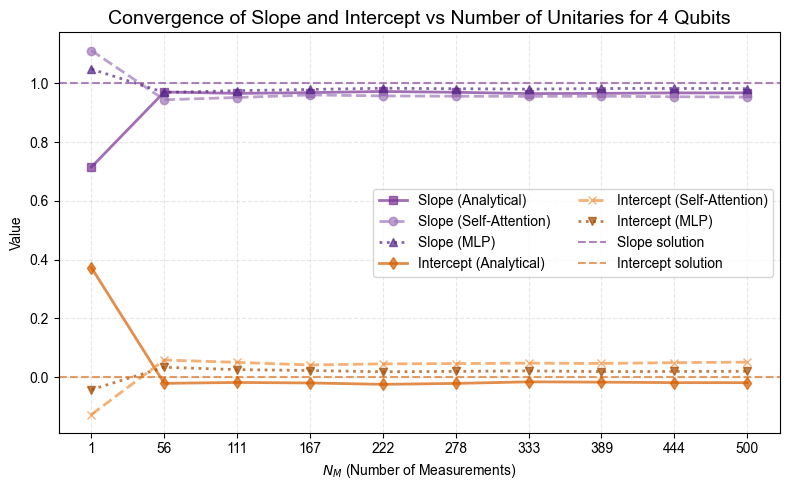

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(slope_vals_brydges, label="Slope (Analytical)", color="#7B3294", linewidth=2, marker="s", alpha=0.7)
plt.plot(slope_vals_attn, label="Slope (Self-Attention)", color="#9E77B8", linewidth=2, marker="o", linestyle="--", alpha=0.7)

plt.plot(slope_vals_mlp, label="Slope (MLP)", color="#542788", linewidth=2, marker="^", linestyle=":", alpha=0.7)
plt.plot(intercept_values_brydges, label="Intercept (Analytical)", color="#D55E00", linewidth=2, marker="d", alpha=0.7)

plt.plot(intercept_values_attn, label="Intercept (Self-Attention)", color="#F18F3B", linewidth=2, marker="x", linestyle="--", alpha=0.7)
plt.plot(intercept_values_mlp, label="Intercept (MLP)", color="#A64B00", linewidth=2, marker="v", linestyle=":", alpha=0.7)

plt.axhline(1, linestyle="--", alpha=0.6, color="#7B3294", label="Slope solution")
plt.axhline(0, linestyle="--", alpha=0.6, color="#D55E00", label="Intercept solution")

plt.title("Convergence of Slope and Intercept vs Number of Unitaries for 4 Qubits", fontsize=14)

unique_uvals = np.unique(Nu_list_4)
plt.xticks(range(len(unique_uvals)), labels=unique_uvals.astype(int))

plt.xlabel(r"$N_M$ (Number of Measurements)")
plt.ylabel("Value")

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(loc="best", frameon=True, ncol=2)

plt.savefig(f"Qubits4_slope_intercept_NU.pdf", format="pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()